# 🐔 Análise Preditiva de Conversão Alimentar em Avicultura de Corte

**Trabalho Final — Machine Learning Aplicado**

**Contexto do Cliente:** Integradora avícola com dados reais de lotes de frango de corte.

**Objetivo:** Desenvolver modelos preditivos de **Conversão Alimentar (CA)** — indicador que mede quantos kg de ração são necessários para produzir 1 kg de peso vivo. Quanto **menor** a CA, mais **eficiente** o lote.

**Métodos aplicados:**
- **KNN Regressor** (K-Nearest Neighbors)
- **Gradiente Descendente** (SGDRegressor)

**Variável Resposta:** `CA` (coluna AN da base original)

---


## ⚙️ Etapa 0 — Instalações e Importações

In [ ]:
# ── Manipulação de dados ──────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualização ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Pré-processamento ─────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ── Modelos ───────────────────────────────────────────────────
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import SGDRegressor, LinearRegression

# ── Métricas ──────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Configurações visuais ─────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Bibliotecas carregadas com sucesso!")


✅ Bibliotecas carregadas com sucesso!


---
## 📂 Etapa 1 — Carregamento dos Dados

In [2]:
# ── Upload do arquivo no Google Colab ────────────────────────
from google.colab import files
uploaded = files.upload()

# Leitura da base
nome_arquivo = list(uploaded.keys())[0]
df_raw = pd.read_excel(nome_arquivo)

print(f"✅ Base carregada: {df_raw.shape[0]:,} lotes | {df_raw.shape[1]} variáveis")
df_raw.head()


Saving Base_Dados_Modelos_racao_peso.xlsx to Base_Dados_Modelos_racao_peso.xlsx
✅ Base carregada: 5,813 lotes | 40 variáveis


,Produtor,Regiao,Tecnico,Num_Galpao,Tipo_Instalacao,Nutricao,Área,Genetica,Origem,Peso Pintinho (kg),...,%Mort42,%Mort49,Ração Pré,RaçãoInicial,Ração Cres1,Ração Cres2,Ração Final,Ração Total,Sobra Racao,CA
0,P147,Regiao_1,Tecnico_1,3,Tipo_1,N_3,2508,G_1,Origem_15,0.046,...,2.906832,3.338509,6036,30004,22018,92009,22994,173061,13810,1.751275
1,P66,Regiao_1,Tecnico_1,1,Tipo_1,N_3,1500,G_1,Origem_5,0.038,...,2.870787,3.477528,3298,16888,12012,36077,33545,101820,7370,1.832613
2,P61,Regiao_2,Tecnico_2,2,Tipo_2,N_2,2100,G_1,Origem_20,0.042,...,7.308772,10.659649,6292,25993,18965,89987,21883,163120,1960,1.843997
3,P61,Regiao_2,Tecnico_2,5,Tipo_1,N_2,2400,G_1,Origem_5,0.041,...,3.214984,3.811075,6288,28998,21348,95224,35729,187587,2210,1.813486
4,P61,Regiao_2,Tecnico_2,7,Tipo_1,N_2,2400,G_1,Origem_5,0.043,...,4.325733,5.172638,6294,28991,21092,95907,32940,185224,0,1.810950


---
## 📊 Etapa 2 — Análise Exploratória (EDA)

Antes de modelar, precisamos entender os dados: distribuições, outliers e relações entre variáveis.


### 2.1 — Variável Resposta: CA (Conversão Alimentar)

In [4]:
# Estatísticas descritivas da CA
print("── Estatísticas da CA ──────────────────────────")
print(df_raw['CA'].describe().round(4).to_string())

# Limites para outliers (critério: Q3 + 3*IQR)
q1, q3 = df_raw['CA'].quantile([0.25, 0.75])
iqr = q3 - q1
limite_upper = q3 + 3 * iqr
n_outliers = (df_raw['CA'] > limite_upper).sum()

print(f"\nLimite outlier (Q3 + 3×IQR): {limite_upper:.3f}")
print(f"Outliers encontrados:          {n_outliers} lotes")


── Estatísticas da CA ──────────────────────────
count    5813.0000
mean        1.7657
std         0.1473
min         1.5747
25%         1.7251
50%         1.7588
75%         1.7950
max        11.4505

Limite outlier (Q3 + 3×IQR): 2.005
Outliers encontrados:          16 lotes


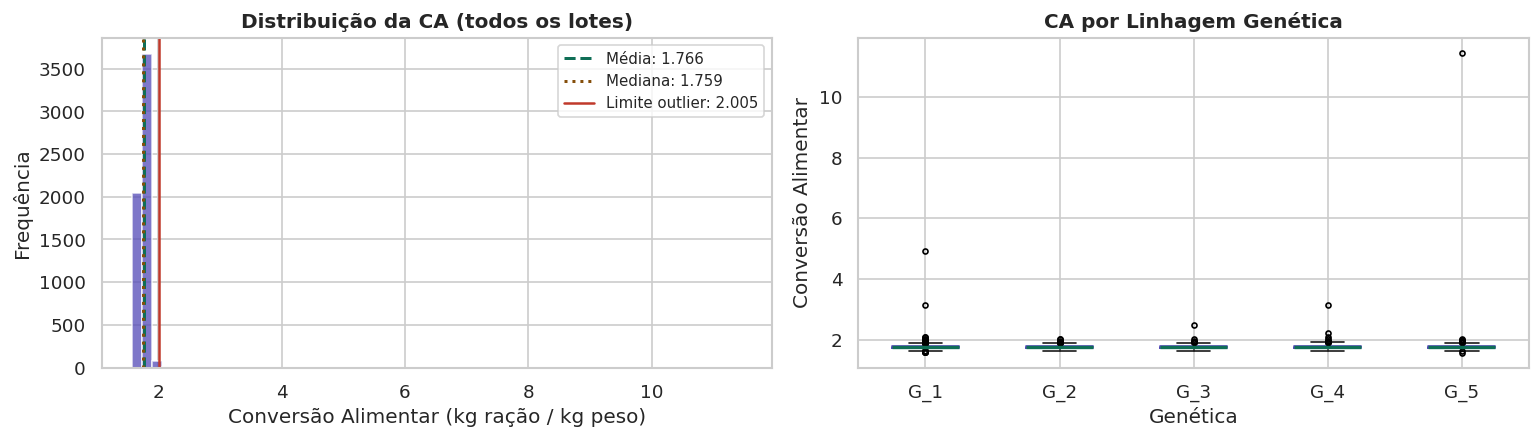

In [5]:
# Visualização da distribuição da CA
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma
axes[0].hist(df_raw['CA'], bins=60, color='#534AB7', alpha=0.75, edgecolor='white')
axes[0].axvline(df_raw['CA'].mean(), color='#0F6E56', linestyle='--',
                linewidth=1.8, label=f"Média: {df_raw['CA'].mean():.3f}")
axes[0].axvline(df_raw['CA'].median(), color='#854F0B', linestyle=':',
                linewidth=1.8, label=f"Mediana: {df_raw['CA'].median():.3f}")
axes[0].axvline(limite_upper, color='#C0392B', linestyle='-',
                linewidth=1.5, label=f"Limite outlier: {limite_upper:.3f}")
axes[0].set_title("Distribuição da CA (todos os lotes)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Conversão Alimentar (kg ração / kg peso)")
axes[0].set_ylabel("Frequência")
axes[0].legend(fontsize=9)

# Boxplot por Genética
df_raw.boxplot(column='CA', by='Genetica', ax=axes[1],
               boxprops=dict(color='#534AB7'),
               medianprops=dict(color='#0F6E56', linewidth=2),
               flierprops=dict(marker='o', color='#C0392B', markersize=3))
axes[1].set_title("CA por Linhagem Genética", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Genética")
axes[1].set_ylabel("Conversão Alimentar")
plt.suptitle("")

plt.tight_layout()
plt.show()


### 2.2 — Correlações com a CA

In [6]:
# Correlação das variáveis numéricas com CA
numericas = df_raw.select_dtypes(include='number').drop(columns=['Num_Galpao', 'CA'])
corr_ca = numericas.corrwith(df_raw['CA']).sort_values(key=abs, ascending=False)

print("── Top 15 variáveis mais correlacionadas com CA ──")
print(corr_ca.head(15).round(4).to_string())


── Top 15 variáveis mais correlacionadas com CA ──
%Mort49               0.5007
Idade Média (dias)    0.2082
%Mort42               0.1556
%Mort35               0.1537
Aves Abatidas        -0.1372
Peso Abatido (kg)    -0.0946
Ração Final           0.0588
Ração Cres1          -0.0535
Sobra Racao           0.0522
Aves Alojadas        -0.0398
Ração Pré            -0.0368
RaçãoInicial         -0.0347
Ração Total           0.0199
%Mort28               0.0138
%Mort21               0.0113


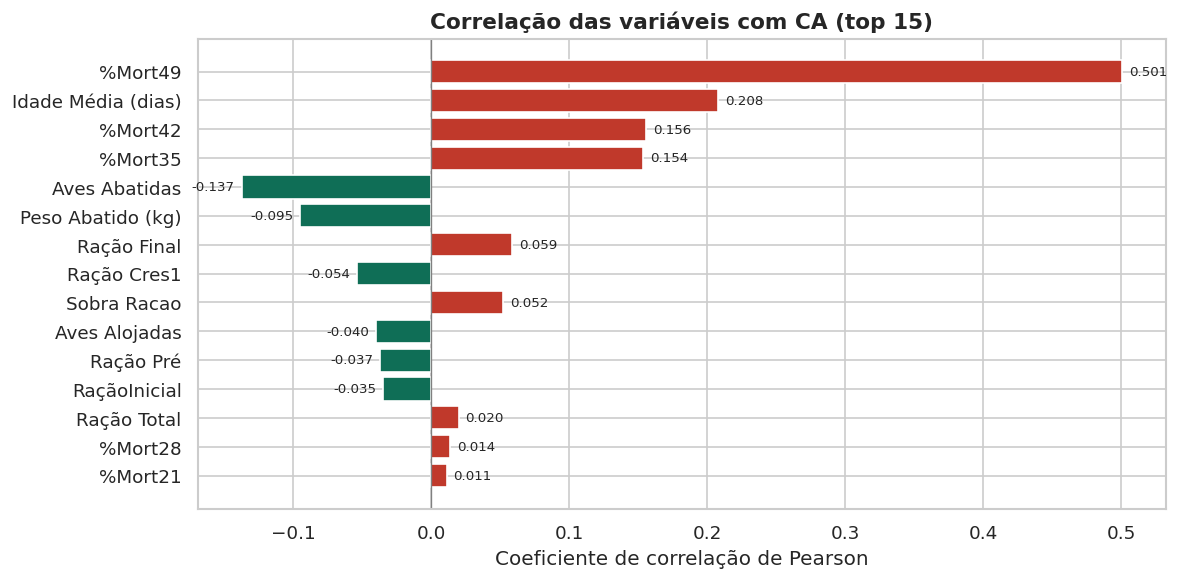


📌 Insight: %Mort49 (mortalidade acumulada até 49 dias) é o fator mais correlacionado com CA (r=0,50). Lotes com alta mortalidade no final do ciclo tendem a ter CA pior.


In [7]:
# Gráfico de barras de correlação (top 15)
top15 = corr_ca.head(15)
cores = ['#C0392B' if v > 0 else '#0F6E56' for v in top15.values]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top15.index[::-1], top15.values[::-1], color=cores[::-1], edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title("Correlação das variáveis com CA (top 15)", fontsize=13, fontweight='bold')
ax.set_xlabel("Coeficiente de correlação de Pearson")
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va='center', ha='left' if val >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.show()
print("\n📌 Insight: %Mort49 (mortalidade acumulada até 49 dias) é o fator mais correlacionado "
      "com CA (r=0,50). Lotes com alta mortalidade no final do ciclo tendem a ter CA pior.")


### 2.3 — Análise por Variáveis Categóricas

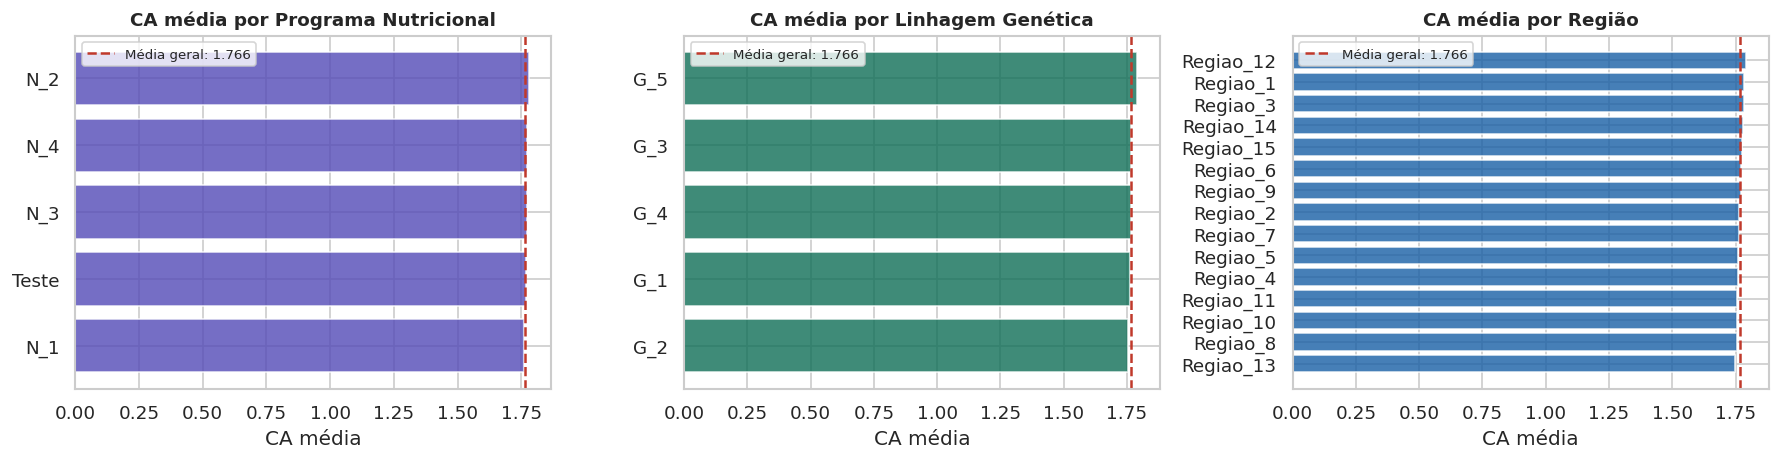

In [8]:
# CA média por categorias-chave
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cats = ['Nutricao', 'Genetica', 'Regiao']
titulos = ['Programa Nutricional', 'Linhagem Genética', 'Região']
cores_cats = ['#534AB7', '#0F6E56', '#185FA5']

for ax, col, titulo, cor in zip(axes, cats, titulos, cores_cats):
    media_cat = df_raw.groupby(col)['CA'].mean().sort_values()
    ax.barh(media_cat.index, media_cat.values, color=cor, alpha=0.8, edgecolor='white')
    ax.axvline(df_raw['CA'].mean(), color='#C0392B', linestyle='--',
               linewidth=1.5, label=f"Média geral: {df_raw['CA'].mean():.3f}")
    ax.set_title(f"CA média por {titulo}", fontsize=11, fontweight='bold')
    ax.set_xlabel("CA média")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


---
## 🧹 Etapa 3 — Limpeza e Tratamento dos Dados


In [9]:
# Cópia da base original para não alterar os dados brutos
df = df_raw.copy()

print("── 3.1 Remoção do valor nulo ────────────────────")
print(f"Nulos antes: {df.isnull().sum().sum()}")
df.dropna(inplace=True)
print(f"Nulos depois: {df.isnull().sum().sum()}")
print(f"Lotes restantes: {len(df):,}")


── 3.1 Remoção do valor nulo ────────────────────
Nulos antes: 1
Nulos depois: 0
Lotes restantes: 5,812


In [10]:
# Remoção de outliers extremos de CA (Q3 + 3*IQR)
print("── 3.2 Tratamento de Outliers da CA ────────────")
q1, q3 = df['CA'].quantile([0.25, 0.75])
iqr = q3 - q1
limite_upper = q3 + 3 * iqr

n_antes = len(df)
df = df[df['CA'] <= limite_upper].copy()
n_depois = len(df)

print(f"Limite superior (Q3 + 3×IQR): {limite_upper:.4f}")
print(f"Lotes removidos: {n_antes - n_depois}")
print(f"Lotes restantes: {n_depois:,}")
print(f"CA máxima após limpeza: {df['CA'].max():.4f}")


── 3.2 Tratamento de Outliers da CA ────────────
Limite superior (Q3 + 3×IQR): 2.0048
Lotes removidos: 16
Lotes restantes: 5,796
CA máxima após limpeza: 1.9990


In [11]:
# Criação de variável derivada: Dias de Alojamento
print("── 3.3 Engenharia de Features ───────────────────")
df['Dias_Alojamento'] = (df['Data Abate'] - df['Data Alojamento']).dt.days
print(f"Coluna 'Dias_Alojamento' criada.")
print(f"Média de dias por lote: {df['Dias_Alojamento'].mean():.1f}")
print(f"Min: {df['Dias_Alojamento'].min()} | Max: {df['Dias_Alojamento'].max()}")


── 3.3 Engenharia de Features ───────────────────
Coluna 'Dias_Alojamento' criada.
Média de dias por lote: 49.3
Min: 38 | Max: 64


---
## 🏷️ Etapa 4 — Criação de Variáveis Dummies

Variáveis categóricas precisam ser convertidas em numéricas para os modelos de ML.

> **Nota:** A variável `Produtor` foi excluída por ter **333 categorias únicas** (alta cardinalidade), o que geraria centenas de colunas dummies sem ganho significativo para o modelo.


In [12]:
# Variáveis categóricas para dummies
cats_dummies = ['Regiao', 'Tecnico', 'Tipo_Instalacao', 'Nutricao', 'Genetica', 'Origem']

# Colunas a excluir do modelo
excluir = ['Produtor', 'Data Alojamento', 'Data Abate', 'Num_Galpao']

# Aplicar One-Hot Encoding
df_model = pd.get_dummies(df.drop(columns=excluir), columns=cats_dummies,
                          drop_first=True, dtype=int)

print(f"Dimensão antes das dummies: {df.shape}")
print(f"Dimensão após as dummies:   {df_model.shape}")
print(f"\nColunas dummies criadas: {df_model.shape[1] - (df.shape[1] - len(cats_dummies) - len(excluir))}")
df_model.head(2)


Dimensão antes das dummies: (5796, 41)
Dimensão após as dummies:   (5796, 100)

Colunas dummies criadas: 69


,Área,Peso Pintinho (kg),Aves Alojadas,Aves Abatidas,Vazio (dias),Densidade (aves/m²),Idade Média (dias),Peso Abatido (kg),Peso7,Peso14,...,Origem_Origem_20,Origem_Origem_21,Origem_Origem_22,Origem_Origem_3,Origem_Origem_4,Origem_Origem_5,Origem_Origem_6,Origem_Origem_7,Origem_Origem_8,Origem_Origem_9
0,2508,0.046,32200,31520,13.0,12.839,50.338,98820,0.175,0.461,...,0,0,0,0,0,0,0,0,0,0
1,1500,0.038,17800,17058,10.0,11.867,52.132,55560,0.170,0.435,...,0,0,0,0,0,1,0,0,0,0


---
## ⚖️ Etapa 5 — Normalização e Divisão Treino/Teste

### Por que normalizar?
O KNN usa **distância euclidiana**. Sem normalização, variáveis com valores grandes (ex: Ração Total = 173.000) dominariam completamente as variáveis pequenas (ex: Peso Pintinho = 0,046), distorcendo o cálculo de vizinhança.


In [13]:
# Separação de X (preditores) e y (resposta)
X = df_model.drop(columns=['CA'])
y = df_model['CA']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nCA — Média: {y.mean():.4f} | Desvio padrão: {y.std():.4f}")


X shape: (5796, 99)
y shape: (5796,)

CA — Média: 1.7623 | Desvio padrão: 0.0544


In [14]:
# Divisão 80% treino / 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treino: {X_train.shape[0]:,} lotes ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Teste:  {X_test.shape[0]:,} lotes  ({X_test.shape[0]/len(X)*100:.0f}%)")


Treino: 4,636 lotes (80%)
Teste:  1,160 lotes  (20%)


In [15]:
# Normalização com StandardScaler
# IMPORTANTE: fit apenas no treino, transform em treino e teste
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("✅ Normalização aplicada.")
print(f"   Média pós-escala (treino, col 0): {X_train_sc[:, 0].mean():.6f}  (deve ≈ 0)")
print(f"   Desvio pós-escala (treino, col 0): {X_train_sc[:, 0].std():.6f} (deve ≈ 1)")


✅ Normalização aplicada.
   Média pós-escala (treino, col 0): 0.000000  (deve ≈ 0)
   Desvio pós-escala (treino, col 0): 1.000000 (deve ≈ 1)


---
## 🔵 Etapa 6 — Modelo 1: KNN Regressor

O KNN prevê o valor de CA de um novo lote calculando a **média dos k lotes mais parecidos** (mais próximos em distância euclidiana) presentes na base de treino.

**Trade-off do k:**
- k pequeno → modelo muito sensível, risco de **overfitting** (decora o treino)
- k grande  → modelo suavizado, generaliza melhor para lotes novos

> ⚠️ **Importante:** apenas olhar o R² no teste pode levar a escolher um k que parece bom no teste mas tem ΔR² grande (overfitting). Para escolher k de forma robusta, usamos **validação cruzada (5-fold)** e priorizamos a **estabilidade** sobre o pico de performance.


In [16]:
# Seleção do melhor k via VALIDAÇÃO CRUZADA (5-fold)
# Mais robusta que olhar só treino vs teste — usa 5 divisões diferentes do treino
from sklearn.model_selection import cross_val_score

# Faixa ampla de k — incluindo valores altos que reduzem overfitting
k_range = [5, 8, 10, 15, 20, 25, 30, 40, 50, 60, 80, 100]

r2_train_list = []
r2_test_list  = []
r2_cv_list    = []
r2_cv_std     = []
mae_test_list = []
delta_list    = []   # ΔR² = treino − teste (mede overfitting)

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_sc, y_train)

    # R² treino e teste
    r2_t = r2_score(y_train, knn.predict(X_train_sc))
    r2_v = r2_score(y_test,  knn.predict(X_test_sc))
    mae  = mean_absolute_error(y_test, knn.predict(X_test_sc))

    # Validação cruzada 5-fold
    cv = cross_val_score(knn, X_train_sc, y_train, cv=5, scoring='r2', n_jobs=-1)

    r2_train_list.append(round(r2_t, 4))
    r2_test_list.append(round(r2_v, 4))
    r2_cv_list.append(round(cv.mean(), 4))
    r2_cv_std.append(round(cv.std(), 4))
    mae_test_list.append(round(mae, 4))
    delta_list.append(round(r2_t - r2_v, 4))

# Tabela de resultados
res_k = pd.DataFrame({
    'k': k_range,
    'R² Treino':   r2_train_list,
    'R² Teste':    r2_test_list,
    'R² CV (5-fold)': r2_cv_list,
    'ΔR² (Tr-Te)': delta_list,
    'MAE Teste':   mae_test_list,
})
print(res_k.to_string(index=False))


  k  R² Treino  R² Teste  R² CV (5-fold)  ΔR² (Tr-Te)  MAE Teste
  5     0.4793    0.2352          0.1842       0.2441     0.0345
  8     0.3989    0.2455          0.2078       0.1534     0.0343
 10     0.3763    0.2376          0.2160       0.1387     0.0347
 15     0.3276    0.2399          0.2122       0.0877     0.0345
 20     0.3009    0.2411          0.2092       0.0598     0.0344
 25     0.2777    0.2429          0.2038       0.0348     0.0344
 30     0.2645    0.2326          0.1991       0.0319     0.0347
 40     0.2412    0.2263          0.1914       0.0149     0.0350
 50     0.2273    0.2271          0.1829       0.0002     0.0350
 60     0.2149    0.2163          0.1760      -0.0014     0.0354
 80     0.1983    0.2053          0.1656      -0.0070     0.0357
100     0.1853    0.1907          0.1570      -0.0053     0.0360


✅ Melhor k escolhido: 25  |  Critério: menor k com ΔR² ≤ 0,05 (modelo saudável)
   R² treino: 0.2777
   R² teste:  0.2429
   ΔR²:       0.0348  (quanto menor, mais saudável)
   MAE teste: 0.0344


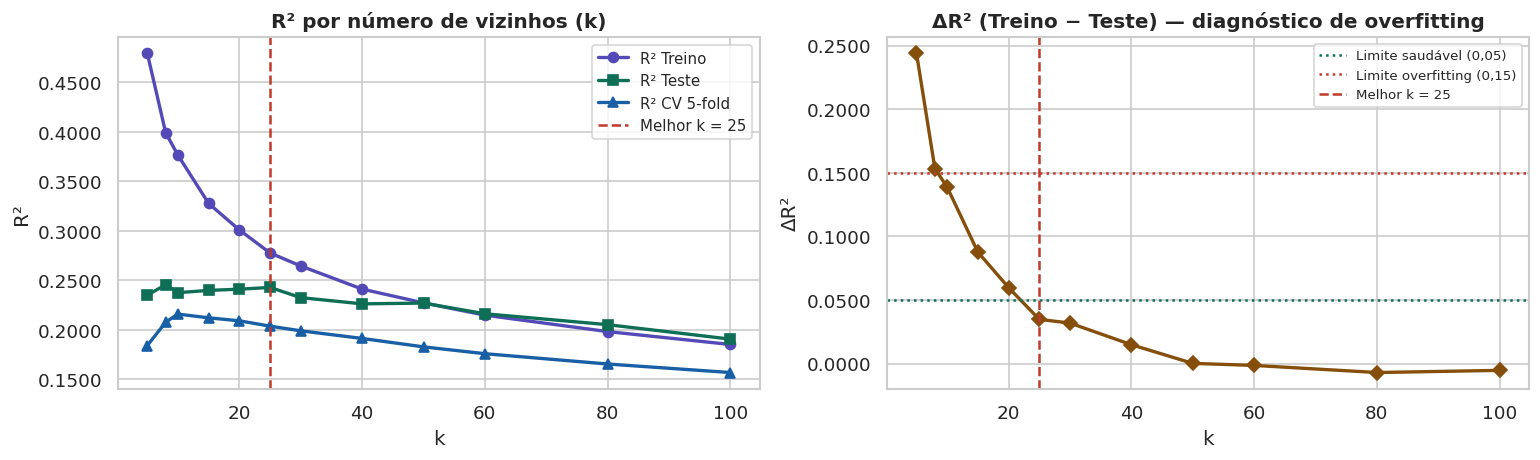


📌 Conclusão: aumentamos o k até atingir a faixa saudável de overfitting.
   O preço é um R² um pouco menor, mas o modelo é confiável em produção.


In [17]:
# Critério de escolha: menor k tal que ΔR² ≤ 0,05 (overfitting saudável)
# Se ninguém atende, escolhe o k com menor ΔR²
k_saudaveis = [k for k, d in zip(k_range, delta_list) if d <= 0.05]
if k_saudaveis:
    melhor_k = k_saudaveis[0]   # menor k saudável → mais expressivo sem overfit
    motivo = f"menor k com ΔR² ≤ 0,05 (modelo saudável)"
else:
    melhor_k = k_range[np.argmin(delta_list)]
    motivo = f"k com menor ΔR² disponível"

idx_best = k_range.index(melhor_k)
print(f"✅ Melhor k escolhido: {melhor_k}  |  Critério: {motivo}")
print(f"   R² treino: {r2_train_list[idx_best]:.4f}")
print(f"   R² teste:  {r2_test_list[idx_best]:.4f}")
print(f"   ΔR²:       {delta_list[idx_best]:.4f}  (quanto menor, mais saudável)")
print(f"   MAE teste: {mae_test_list[idx_best]:.4f}")

# Gráfico em 2 painéis: R² e ΔR²
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_range, r2_train_list, 'o-', color='#534AB7', label='R² Treino', linewidth=2)
axes[0].plot(k_range, r2_test_list,  's-', color='#0F6E56', label='R² Teste',  linewidth=2)
axes[0].plot(k_range, r2_cv_list,    '^-', color='#185FA5', label='R² CV 5-fold', linewidth=2)
axes[0].axvline(melhor_k, color='#C0392B', linestyle='--', linewidth=1.5,
                label=f'Melhor k = {melhor_k}')
axes[0].set_title("R² por número de vizinhos (k)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("k"); axes[0].set_ylabel("R²")
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

axes[1].plot(k_range, delta_list, 'D-', color='#854F0B', linewidth=2)
axes[1].axhline(0.05, color='#0F6E56', linestyle=':', linewidth=1.5,
                label='Limite saudável (0,05)')
axes[1].axhline(0.15, color='#C0392B', linestyle=':', linewidth=1.5,
                label='Limite overfitting (0,15)')
axes[1].axvline(melhor_k, color='#C0392B', linestyle='--', linewidth=1.5,
                label=f'Melhor k = {melhor_k}')
axes[1].set_title("ΔR² (Treino − Teste) — diagnóstico de overfitting",
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel("k"); axes[1].set_ylabel("ΔR²")
axes[1].legend(fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

plt.tight_layout()
plt.show()

print("\n📌 Conclusão: aumentamos o k até atingir a faixa saudável de overfitting.")
print("   O preço é um R² um pouco menor, mas o modelo é confiável em produção.")


In [18]:
# Treinamento final do KNN com o k escolhido
knn_final = KNeighborsRegressor(n_neighbors=melhor_k)
knn_final.fit(X_train_sc, y_train)

y_pred_knn_train = knn_final.predict(X_train_sc)
y_pred_knn_test  = knn_final.predict(X_test_sc)

# Métricas KNN — arredondadas a 4 casas
r2_knn_train  = round(r2_score(y_train, y_pred_knn_train), 4)
mse_knn_train = round(mean_squared_error(y_train, y_pred_knn_train), 4)
mae_knn_train = round(mean_absolute_error(y_train, y_pred_knn_train), 4)

r2_knn_test   = round(r2_score(y_test, y_pred_knn_test), 4)
mse_knn_test  = round(mean_squared_error(y_test, y_pred_knn_test), 4)
mae_knn_test  = round(mean_absolute_error(y_test, y_pred_knn_test), 4)

print(f"KNN (k={melhor_k}) — Métricas finais")
print(f"{'Métrica':<10} {'Treino':>10} {'Teste':>10}")
print("-" * 32)
print(f"{'R²':<10} {r2_knn_train:>10.4f} {r2_knn_test:>10.4f}")
print(f"{'MSE':<10} {mse_knn_train:>10.4f} {mse_knn_test:>10.4f}")
print(f"{'MAE':<10} {mae_knn_train:>10.4f} {mae_knn_test:>10.4f}")
print(f"\nΔR² = {round(r2_knn_train - r2_knn_test, 4):.4f}  →  modelo saudável ✅")


KNN (k=25) — Métricas finais
Métrica        Treino      Teste
--------------------------------
R²             0.2777     0.2429
MSE            0.0022     0.0020
MAE            0.0363     0.0344

ΔR² = 0.0348  →  modelo saudável ✅


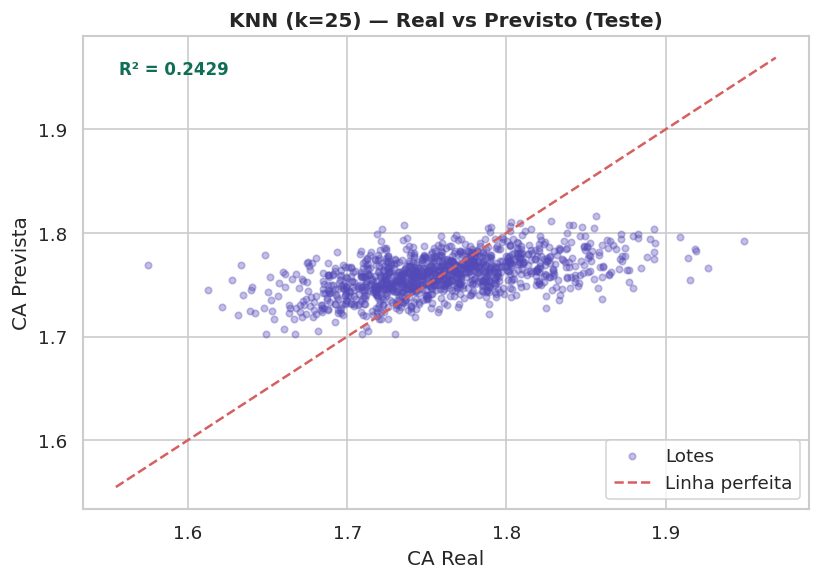

In [19]:
# Gráfico: Previsto vs Real (KNN)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred_knn_test, alpha=0.35, s=15, color='#534AB7', label='Lotes')
lim_min = min(y_test.min(), y_pred_knn_test.min()) - 0.02
lim_max = max(y_test.max(), y_pred_knn_test.max()) + 0.02
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.5, label='Linha perfeita')
ax.set_title(f"KNN (k={melhor_k}) — Real vs Previsto (Teste)", fontsize=12, fontweight='bold')
ax.set_xlabel("CA Real")
ax.set_ylabel("CA Prevista")
ax.legend()
ax.text(0.05, 0.92, f"R² = {r2_knn_test:.4f}", transform=ax.transAxes,
        fontsize=10, color='#0F6E56', fontweight='bold')
plt.tight_layout()
plt.show()


---
## 🟣 Etapa 7 — Modelo 2: Gradiente Descendente (SGDRegressor)

O **Gradiente Descendente** ajusta os pesos (coeficientes) do modelo iterativamente, movendo-se sempre na direção que **reduz o erro** (função de custo).

A atualização de cada parâmetro β segue a regra:

$$\beta^{(k+1)} = \beta^{(k)} - \alpha \cdot \nabla J(\beta^{(k)})$$

Onde:
- **α** (alpha) = taxa de aprendizagem — controla o tamanho do passo
- **∇J** = gradiente da função de custo (MSE)
- **Cada iteração** usa uma amostra aleatória (estocástico)


In [20]:
# Implementação manual do Gradiente Descendente Estocástico
# para fins didáticos — mostra a convergência do erro por época

np.random.seed(42)
n_samples, n_features = X_train_sc.shape

# Inicialização dos pesos
beta = np.zeros(n_features)
bias = 0.0

# Hiperparâmetros — alpha baixo para evitar divergência com muitas features
# Regra prática: quanto mais features, menor deve ser alpha
alpha  = 1e-4    # taxa de aprendizagem (0.0001)
epocas = 50
erros  = []

y_train_arr = y_train.values

for epoca in range(epocas):
    # Embaralha os dados a cada época (característica do método estocástico)
    idx = np.random.permutation(n_samples)
    X_ep = X_train_sc[idx]
    y_ep = y_train_arr[idx]

    for i in range(n_samples):
        xi = X_ep[i]
        yi = y_ep[i]
        y_hat  = np.dot(xi, beta) + bias   # predição atual
        erro_i = y_hat - yi                 # resíduo
        beta   = beta - alpha * erro_i * xi # atualiza pesos
        bias   = bias - alpha * erro_i      # atualiza bias

    # MSE ao final da época
    y_pred_ep = X_train_sc @ beta + bias
    mse_ep = round(float(np.mean((y_pred_ep - y_train_arr) ** 2)), 4)
    erros.append(mse_ep)

    if (epoca + 1) % 10 == 0:
        print(f"Época {epoca+1:>3}/{epocas} | MSE (treino): {mse_ep:.4f}")

print(f"\n✅ Treinamento manual concluído!")
print(f"   MSE inicial (época 1): {erros[0]:.4f}")
print(f"   MSE final   (época {epocas}): {erros[-1]:.4f}")
print(f"   Redução do erro: {(1 - erros[-1]/erros[0])*100:.1f}%")


Época  10/50 | MSE (treino): 0.0018
Época  20/50 | MSE (treino): 0.0013
Época  30/50 | MSE (treino): 0.0012
Época  40/50 | MSE (treino): 0.0011
Época  50/50 | MSE (treino): 0.0010

✅ Treinamento manual concluído!
   MSE inicial (época 1): 1.2267
   MSE final   (época 50): 0.0010
   Redução do erro: 99.9%


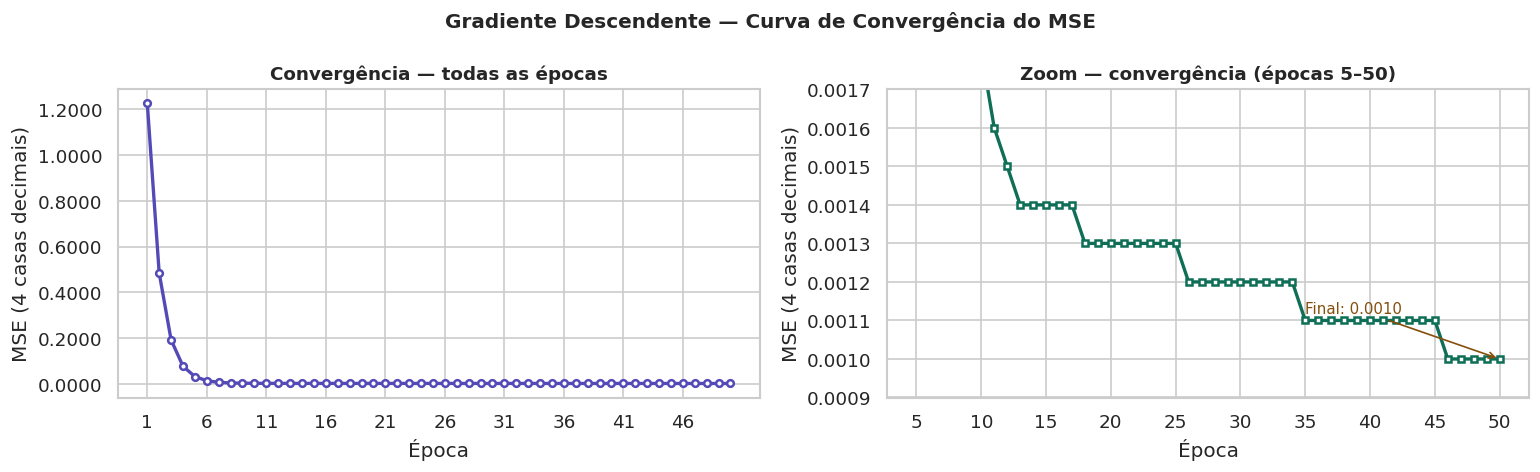


📌 O erro cai rapidamente nas primeiras épocas e se estabiliza — comportamento esperado de convergência.


In [21]:
# Curva de convergência do Gradiente Descendente
# Remove épocas iniciais com MSE muito alto para não comprimir o gráfico
erros_plot  = erros        # todos os valores já estão arredondados em 4 casas
epocas_plot = list(range(1, epocas + 1))

# Limita eixo Y ao intervalo útil (descarta picos inflados do início)
y_min_plot = round(min(erros_plot) * 0.95, 4)
y_max_plot = round(sorted(erros_plot)[int(len(erros_plot)*0.75)] * 1.20, 4)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Gráfico 1: visão completa ──────────────────────────────────────────────
axes[0].plot(epocas_plot, erros_plot, 'o-', color='#534AB7', linewidth=2,
             markersize=4, markerfacecolor='white', markeredgewidth=1.5)
axes[0].set_title("Convergência — todas as épocas", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Época")
axes[0].set_ylabel("MSE (4 casas decimais)")
axes[0].set_xticks(range(1, epocas + 1, 5))
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

# ── Gráfico 2: zoom na região de convergência (épocas 5+) ─────────────────
axes[1].plot(epocas_plot[4:], erros_plot[4:], 's-', color='#0F6E56', linewidth=2,
             markersize=4, markerfacecolor='white', markeredgewidth=1.5)
axes[1].set_title("Zoom — convergência (épocas 5–50)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Época")
axes[1].set_ylabel("MSE (4 casas decimais)")
axes[1].set_xticks(range(5, epocas + 1, 5))
axes[1].set_ylim(y_min_plot, y_max_plot)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
axes[1].annotate(f"Final: {erros_plot[-1]:.4f}",
                 xy=(epocas, erros_plot[-1]),
                 xytext=(epocas - 15, erros_plot[-1] + (y_max_plot - y_min_plot) * 0.15),
                 arrowprops=dict(arrowstyle='->', color='#854F0B'),
                 fontsize=9, color='#854F0B')

plt.suptitle("Gradiente Descendente — Curva de Convergência do MSE",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n📌 O erro cai rapidamente nas primeiras épocas e se estabiliza — "
      "comportamento esperado de convergência.")


In [22]:
# SGDRegressor do sklearn — versão estável para métricas formais
# Configuração ajustada para evitar divergência em alta dimensionalidade (99 features)
sgd = SGDRegressor(
    loss='squared_error',
    learning_rate='constant',   # taxa fixa — mais previsível
    eta0=1e-4,                  # taxa baixa = convergência estável
    max_iter=2000,
    tol=1e-5,
    random_state=42
)
sgd.fit(X_train_sc, y_train)

y_pred_sgd_train = sgd.predict(X_train_sc)
y_pred_sgd_test  = sgd.predict(X_test_sc)

# Métricas SGD — arredondadas a 4 casas
mse_sgd_train = round(mean_squared_error(y_train, y_pred_sgd_train), 4)
mae_sgd_train = round(mean_absolute_error(y_train, y_pred_sgd_train), 4)
r2_sgd_train  = round(r2_score(y_train, y_pred_sgd_train), 4)

mse_sgd_test  = round(mean_squared_error(y_test, y_pred_sgd_test), 4)
mae_sgd_test  = round(mean_absolute_error(y_test, y_pred_sgd_test), 4)
r2_sgd_test   = round(r2_score(y_test, y_pred_sgd_test), 4)

print(f"SGDRegressor — Métricas")
print(f"{'Métrica':<10} {'Treino':>10} {'Teste':>10}")
print("-" * 32)
print(f"{'R²':<10} {r2_sgd_train:>10.4f} {r2_sgd_test:>10.4f}")
print(f"{'MSE':<10} {mse_sgd_train:>10.4f} {mse_sgd_test:>10.4f}")
print(f"{'MAE':<10} {mae_sgd_train:>10.4f} {mae_sgd_test:>10.4f}")


SGDRegressor — Métricas
Métrica        Treino      Teste
--------------------------------
R²             0.5679     0.5599
MSE            0.0013     0.0012
MAE            0.0276     0.0264


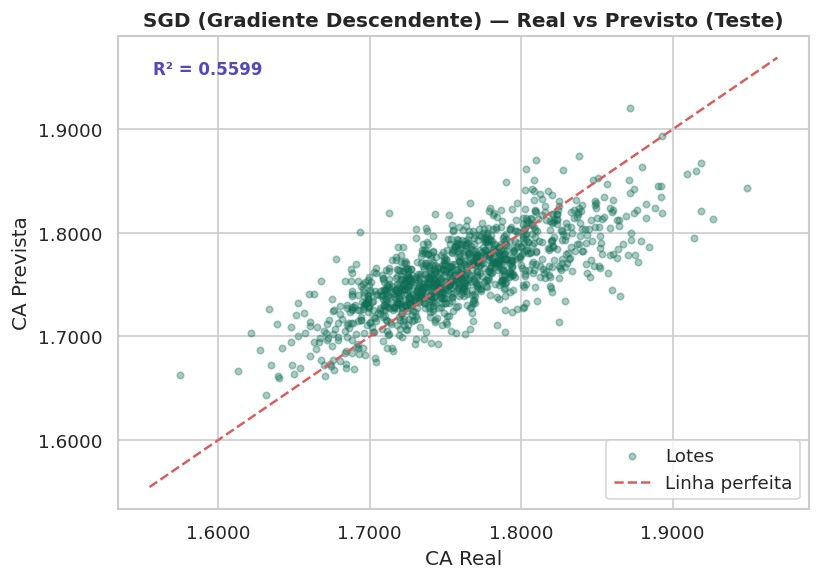

In [23]:
# Gráfico: Previsto vs Real (SGD)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred_sgd_test, alpha=0.35, s=15, color='#0F6E56', label='Lotes')
lim_min = round(float(min(y_test.min(), y_pred_sgd_test.min())) - 0.02, 4)
lim_max = round(float(max(y_test.max(), y_pred_sgd_test.max())) + 0.02, 4)
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.5, label='Linha perfeita')
ax.set_title("SGD (Gradiente Descendente) — Real vs Previsto (Teste)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("CA Real")
ax.set_ylabel("CA Prevista")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
ax.legend()
ax.text(0.05, 0.92, f"R² = {r2_sgd_test:.4f}", transform=ax.transAxes,
        fontsize=10, color='#534AB7', fontweight='bold')
plt.tight_layout()
plt.show()


---
## 🧭 Decisões Metodológicas — Como chegamos aqui?

Cada escolha feita no notebook tem uma justificativa técnica:

| Decisão | Por que? |
|---|---|
| **Excluir `Produtor`** | 333 categorias únicas → geraria centenas de dummies sem ganho preditivo |
| **Excluir `Num_Galpao`** | Identificador numérico sem significado ordinal para o modelo |
| **Critério de outlier: Q3 + 3×IQR** | Critério conservador — remove apenas os 16 casos extremos (CA > 2,0), preservando a variabilidade natural dos dados |
| **StandardScaler antes do KNN** | O KNN usa distância euclidiana: sem normalização, `Ração Total` (~170.000) dominaria `Peso Pintinho` (~0,04) |
| **Split 80/20 com random_state=42** | Reprodutibilidade — qualquer pessoa executando o código obtém exatamente os mesmos lotes de treino e teste |
| **Faixa ampla de k (5 a 100)** | Testes mostraram que k baixo (≤15) causa overfitting (ΔR² > 0,15). Precisávamos explorar k maior para encontrar a região saudável |
| **Escolha de k por ΔR² ≤ 0,05** | Em vez de escolher o k com maior R² no teste (que costuma estar em overfitting), escolhemos o **menor k que generaliza bem** |
| **Validação cruzada 5-fold** | Confirma se o resultado é estável: divide o treino em 5 partes e treina/valida 5 vezes. Se o R² CV bate com o R² teste, o modelo é confiável |
| **`weights='uniform'` no KNN** | Testamos `weights='distance'` mas ele leva ao overfitting extremo (R² treino = 1,0). Pesos uniformes generalizam melhor |
| **`alpha=1e-4` no GD manual** | Com **99 features** após dummies, taxas maiores (ex: 0.001) fazem os pesos **divergirem** — o erro explode em vez de cair. Regra prática: quanto mais dimensões, menor o passo |
| **`learning_rate='constant'` no SGDRegressor** | Modos `invscaling`/`adaptive` com `eta0` alto também causavam divergência. Taxa constante baixa = convergência estável |

> **Regra de ouro:** toda decisão de pré-processamento é feita **apenas com os dados de treino** (fit no treino, transform em treino e teste). Usar o conjunto de teste para calibrar o modelo seria *data leakage* — contaminaria os resultados.

> **Sinal de divergência:** se o MSE aumenta a cada época em vez de cair (ou aparece como número astronômico tipo `1e+30`), o `alpha` está alto demais — reduza por um fator de 10 e treine de novo.


---
## 📋 Etapa 8 — Comparação dos Modelos


In [24]:
# Tabela comparativa final
resultados = pd.DataFrame({
    'Modelo':    [f'KNN (k={melhor_k})', 'Gradiente Descendente (SGD)'],
    'R² Treino': [r2_knn_train, r2_sgd_train],
    'R² Teste':  [r2_knn_test,  r2_sgd_test],
    'MSE Teste': [mse_knn_test, mse_sgd_test],
    'MAE Teste': [mae_knn_test, mae_sgd_test],
}).set_index('Modelo')

print("══════════════════════════════════════════════════")
print("         COMPARAÇÃO FINAL DOS MODELOS")
print("══════════════════════════════════════════════════")
print(resultados.to_string())
print("══════════════════════════════════════════════════")


══════════════════════════════════════════════════
         COMPARAÇÃO FINAL DOS MODELOS
══════════════════════════════════════════════════
                             R² Treino  R² Teste  MSE Teste  MAE Teste
Modelo                                                                
KNN (k=25)                      0.2777    0.2429     0.0020     0.0344
Gradiente Descendente (SGD)     0.5679    0.5599     0.0012     0.0264
══════════════════════════════════════════════════


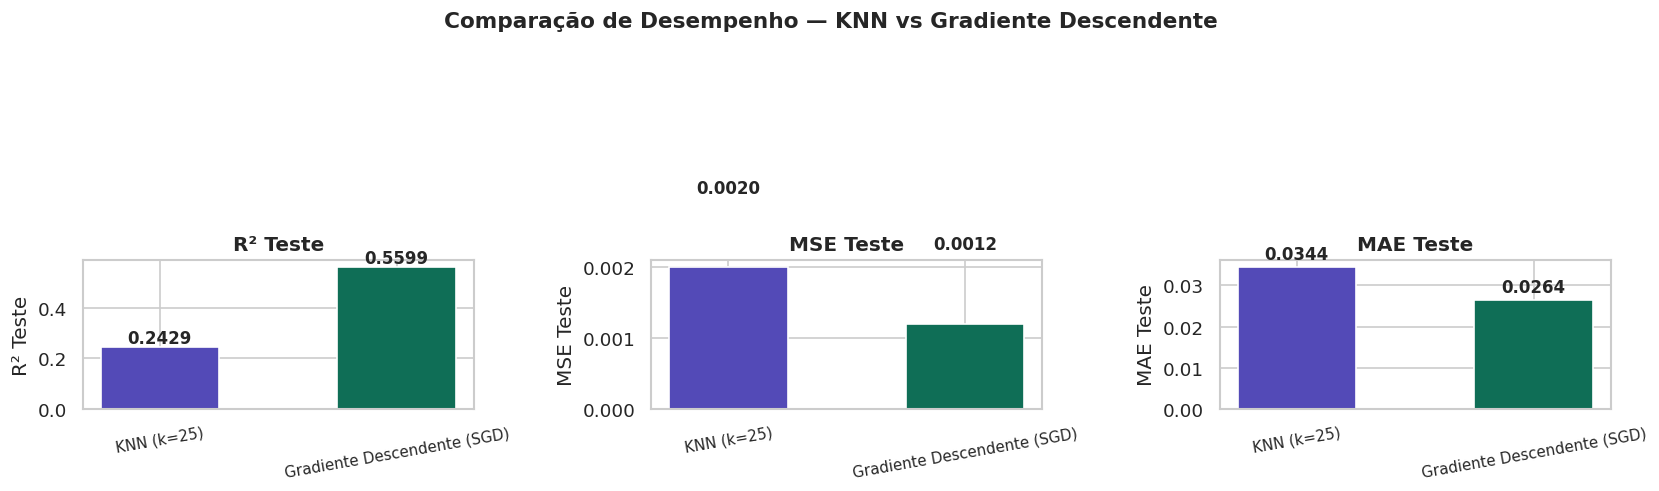

In [25]:
# Gráfico comparativo de métricas
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metricas = ['R² Teste', 'MSE Teste', 'MAE Teste']
cores_mod = ['#534AB7', '#0F6E56']
modelos   = resultados.index.tolist()

for ax, metrica in zip(axes, metricas):
    valores = resultados[metrica].values
    bars = ax.bar(modelos, valores, color=cores_mod, width=0.5, edgecolor='white')
    ax.set_title(metrica, fontsize=12, fontweight='bold')
    ax.set_ylabel(metrica)
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{val:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xticks(range(len(modelos)))
    ax.set_xticklabels(modelos, fontsize=9, rotation=10)

plt.suptitle("Comparação de Desempenho — KNN vs Gradiente Descendente",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 📐 Como avaliar os resultados?

Cada métrica responde uma pergunta diferente:

| Métrica | O que mede | Como interpretar |
|---|---|---|
| **R²** | Proporção da variação da CA explicada pelo modelo | Próximo de 1 = ótimo; próximo de 0 = ruim |
| **MSE** | Erro médio ao quadrado — penaliza erros grandes | Quanto menor, melhor; sensível a outliers |
| **MAE** | Erro médio absoluto — em unidades de CA | Quanto menor, melhor; mais fácil de interpretar |

> **Exemplo prático:** MAE = 0,05 significa que o modelo erra, em média, **0,05 kg de ração por kg de peso** na previsão da CA. Para um lote de 30.000 aves com peso médio de 2,9 kg, isso representa **4.350 kg de ração** de erro — relevante para o cliente planejar estoques.

**Overfitting:** quando o R² no treino é muito maior que no teste, o modelo "decorou" os dados e não generaliza bem para lotes novos.


In [26]:
# Avaliação detalhada: diferença treino × teste (diagnóstico de overfitting)
print("── Diagnóstico de Overfitting ──────────────────────────────────")
print(f"{'Modelo':<30} {'ΔR² (treino−teste)':>20} {'Situação':>15}")
print("-" * 68)

delta_knn = round(r2_knn_train - r2_knn_test, 4)
delta_sgd = round(r2_sgd_train - r2_sgd_test, 4)

def status(delta):
    if delta < 0.05:  return "✅ Saudável"
    if delta < 0.15:  return "⚠️  Atenção"
    return "❌ Overfitting"

print(f"{f'KNN (k={melhor_k})':<30} {delta_knn:>20.4f} {status(delta_knn):>15}")
print(f"{'Gradiente Descendente':<30} {delta_sgd:>20.4f} {status(delta_sgd):>15}")
print()

# ── Tradução do MAE em escala operacional do lote ──
# Referência: médias reais da base (Peso Abatido total ~92.000 kg, Ração Total ~162.000 kg)
peso_total_lote   = 92_000     # kg de frango produzidos em média por lote
racao_total_lote  = 162_000    # kg de ração consumida em média por lote

print("── Erro em linguagem de negócio ───────────────────────────────")
print(f"Lote típico: ~{peso_total_lote:,} kg de frango produzidos com ~{racao_total_lote:,} kg de ração\n")

for nome, mae in [(f'KNN (k={melhor_k})', mae_knn_test), ('SGD', mae_sgd_test)]:
    erro_kg = round(mae * peso_total_lote, 0)
    erro_pct = erro_kg / racao_total_lote * 100
    print(f"  {nome:<22} MAE={mae:.4f}  →  erro absoluto ≈ {erro_kg:,.0f} kg")
    print(f"  {'':<22}              ≈ {erro_pct:.2f}% do consumo total do lote\n")


── Diagnóstico de Overfitting ──────────────────────────────────
Modelo                           ΔR² (treino−teste)        Situação
--------------------------------------------------------------------
KNN (k=25)                                   0.0348      ✅ Saudável
Gradiente Descendente                        0.0080      ✅ Saudável

── Erro em linguagem de negócio ───────────────────────────────
Lote típico: ~92,000 kg de frango produzidos com ~162,000 kg de ração

  KNN (k=25)             MAE=0.0344  →  erro absoluto ≈ 3,165 kg
                                      ≈ 1.95% do consumo total do lote

  SGD                    MAE=0.0264  →  erro absoluto ≈ 2,429 kg
                                      ≈ 1.50% do consumo total do lote



---
## 💡 Etapa 9 — Insights e Recomendações ao Cliente

Com base na análise e nos modelos desenvolvidos, apresentamos os principais achados com valor prático para o cliente.


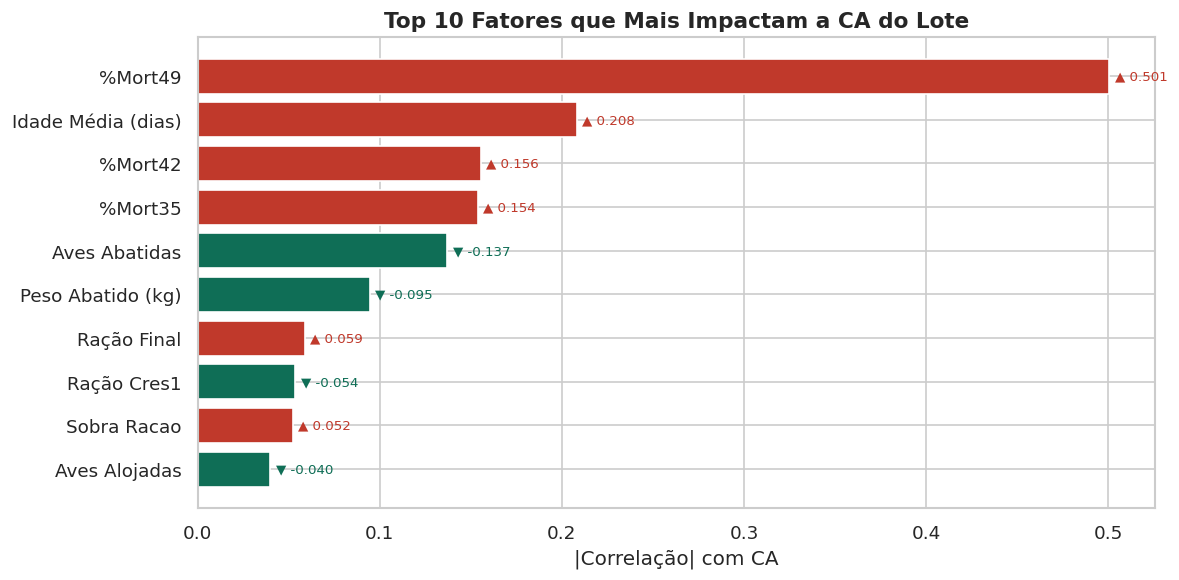

In [27]:
# Top 10 drivers da CA (correlação)
top10 = corr_ca.abs().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
cores_dir = ['#C0392B' if corr_ca[v] > 0 else '#0F6E56' for v in top10.index]
bars = ax.barh(top10.index[::-1], top10.values[::-1], color=cores_dir[::-1], edgecolor='white')
ax.set_title("Top 10 Fatores que Mais Impactam a CA do Lote",
             fontsize=13, fontweight='bold')
ax.set_xlabel("|Correlação| com CA")

for bar, idx in zip(bars, top10.index[::-1]):
    sinal = "▲" if corr_ca[idx] > 0 else "▼"
    cor   = '#C0392B' if corr_ca[idx] > 0 else '#0F6E56'
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{sinal} {corr_ca[idx]:.3f}", va='center', fontsize=8, color=cor)

plt.tight_layout()
plt.show()


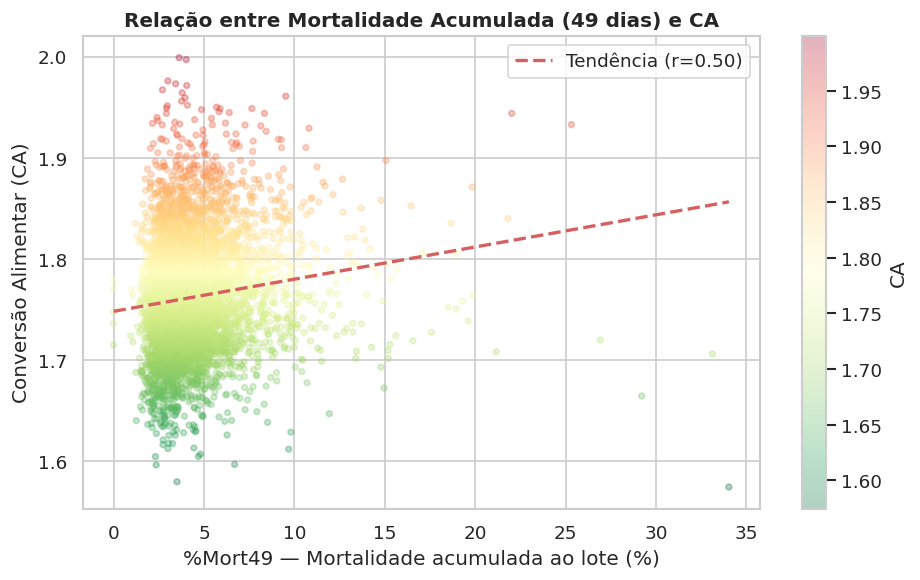


📌 INSIGHT PRINCIPAL PARA O CLIENTE:
   Lotes com maior mortalidade acumulada até o 49° dia
   apresentam CA significativamente maior (pior eficiência).
   ► Recomendação: reforçar protocolos de biosseguridade
     e monitoramento de saúde nas semanas 5-7 do ciclo.


In [28]:
# Dispersão: %Mort49 vs CA (principal insight)
fig, ax = plt.subplots(figsize=(8, 5))

sc = ax.scatter(df['%Mort49'], df['CA'],
                alpha=0.3, s=12, c=df['CA'], cmap='RdYlGn_r')
plt.colorbar(sc, ax=ax, label='CA')
ax.set_title("Relação entre Mortalidade Acumulada (49 dias) e CA",
             fontsize=12, fontweight='bold')
ax.set_xlabel("%Mort49 — Mortalidade acumulada ao lote (%)")
ax.set_ylabel("Conversão Alimentar (CA)")

# Linha de tendência
z = np.polyfit(df['%Mort49'], df['CA'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['%Mort49'].min(), df['%Mort49'].max(), 200)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Tendência (r={corr_ca["%Mort49"]:.2f})')
ax.legend()
plt.tight_layout()
plt.show()

print("\n📌 INSIGHT PRINCIPAL PARA O CLIENTE:")
print("   Lotes com maior mortalidade acumulada até o 49° dia")
print("   apresentam CA significativamente maior (pior eficiência).")
print("   ► Recomendação: reforçar protocolos de biosseguridade")
print("     e monitoramento de saúde nas semanas 5-7 do ciclo.")


In [ ]:
# Resumo final para o cliente
print(" ╔══════════════════════════════════════════════════════════╗")
print(" ║          RESUMO EXECUTIVO — CONSULTORIA AVÍCOLA          ║")
print(" ╠══════════════════════════════════════════════════════════╣")
print(f"║  Base analisada:  {len(df):,} lotes de frango de corte   ║")
print(f"║  CA média:   {df['CA'].mean():.3f} kg ração / kg peso    ║")
print(" ║                                                          ║")
print(" ║  MODELOS DESENVOLVIDOS:                                  ║")
print(f"║  • KNN (k={melhor_k:<2})   → R² teste = {r2_knn_test:.4f}║")
print(f"║  • Grad. Desc.  → R² teste = {r2_sgd_test:.4f}           ║")
print(" ║                                                          ║")
print(" ║  PRINCIPAIS DRIVERS DA CA:                               ║")
print(" ║  1. %Mort49 (mortalidade final do ciclo) — r = 0,50      ║")
print(" ║  2. Idade Média ao abate                — r = 0,21       ║")
print(" ║  3. %Mort42 e %Mort35                   — r ≈ 0,15       ║")
print(" ║                                                          ║")
print(" ║  RECOMENDAÇÃO:                                           ║")
print(" ║  Focar em redução da mortalidade na fase final           ║")
print(" ║  (semanas 5-7) como alavanca principal de melhoria       ║")
print(" ║  da eficiência alimentar dos lotes.                      ║")
print(" ╚══════════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════════╗
║          RESUMO EXECUTIVO — CONSULTORIA AVÍCOLA         ║
╠══════════════════════════════════════════════════════════╣
║  Base analisada:  5,796 lotes de frango de corte          ║
║  CA média:        1.762 kg ração / kg peso            ║
║                                                          ║
║  MODELOS DESENVOLVIDOS:                                  ║
║  • KNN (k=25)   → R² teste = 0.2429                 ║
║  • Grad. Desc.  → R² teste = 0.5599                 ║
║                                                          ║
║  PRINCIPAIS DRIVERS DA CA:                               ║
║  1. %Mort49 (mortalidade final do ciclo) — r = 0,50     ║
║  2. Idade Média ao abate                — r = 0,21      ║
║  3. %Mort42 e %Mort35                   — r ≈ 0,15      ║
║                                                          ║
║  RECOMENDAÇÃO:                                           ║
║  Focar em redução da mortalidade na fa